First, check that you are running in a GPU environment. The following command should show you the GPU information:

In [1]:
!nvidia-smi

Mon Jun 30 15:09:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.07             Driver Version: 570.133.07     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 Ti     Off |   00000000:01:00.0  On |                  N/A |
| 30%   33C    P3             41W /  200W |    3112MiB /   8192MiB |     33%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Install Ultralytics

In [5]:
!pip install ultralytics --quiet

In [3]:
from ultralytics import YOLO

[OPTIONAL] Classify a sample image with the base model

In [6]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://miro.medium.com/v2/resize:fit:1400/1*qNkH4lxA670j1d9OWh1lww.png'

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/marco/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.161 🚀 Python-3.8.20 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7828MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

100%|████████████████████████████████████████| 887k/887k [00:00<00:00, 1.12MB/s]
image 1/1 /home/marco/git_projects/yolo-licence-plate-training/1*qNkH4lxA670j1d9OWh1lww.png: 448x640 7 persons, 6 bicycles, 5 cars, 1 traffic light, 2 stop signs, 30.6ms
Speed: 1.3ms preprocess, 30.6ms inference, 65.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


This image should be obtained

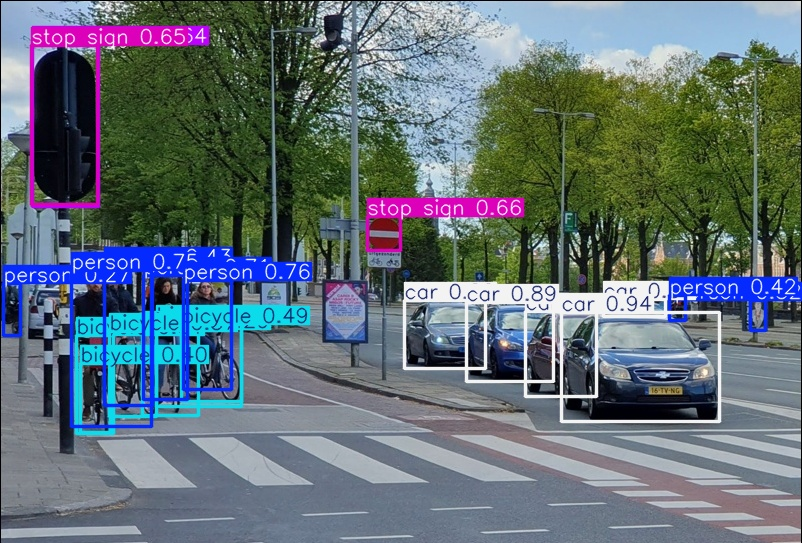

# Train custom model

First, upload the dataset to Colab, or else to Drive and mount it to the Colab instance.

If you mount your Google Drive, the "data" variable in the next command will contain something like "../content/drive/MyDrive/Datasets/CarPlate/data.yaml". Else, if you manually upload the dataset to Colab without using drive, pass the data.yaml path to the "data" variable.

> Check the content of data.yaml, the path variable on the first line can contain the url to the drive dataset or the path to the dataset uploaded to your Colab virtual machine.

To train the model, run the following

In [ ]:
!yolo task=detect mode=train model=yolov8n.pt data=data.yaml epochs=300 imgsz=640 pretrained=True augment=True

Ultralytics YOLOv8.2.64 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=../content/drive/MyDrive/Datasets/CarPlate/data.yaml, epochs=500, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=

After training, the trained models should be in ./runs/detect/train/weights. There are two models: best.pt and last.pt. It is recommended to use best.pt

> Note: each time you run the train command, a new run directory is created in the `runs/detect/train` directory. For example, the first time, the train folder is created, and the second time, train2 is generated

To export the model to .ncnn format, use the following command (after training):

In [ ]:
!yolo export model=./runs/detect/train/weights/best.pt format=ncnn

To download the files to your local machine, you can use the following command:

In [ ]:
!zip -r trained-model.zip /content/runs/

  adding: content/runs/detect/train5/ (stored 0%)
  adding: content/runs/detect/train5/F1_curve.png (deflated 15%)
  adding: content/runs/detect/train5/PR_curve.png (deflated 27%)
  adding: content/runs/detect/train5/weights/ (stored 0%)
  adding: content/runs/detect/train5/weights/last.pt (deflated 10%)
  adding: content/runs/detect/train5/weights/best.pt (deflated 9%)
  adding: content/runs/detect/train5/args.yaml (deflated 52%)
  adding: content/runs/detect/train5/train_batch0.jpg (deflated 4%)
  adding: content/runs/detect/train5/train_batch1.jpg (deflated 6%)
  adding: content/runs/detect/train5/results.csv (deflated 86%)
  adding: content/runs/detect/train5/val_batch0_pred.jpg (deflated 16%)
  adding: content/runs/detect/train5/R_curve.png (deflated 17%)
  adding: content/runs/detect/train5/labels.jpg (deflated 40%)
  adding: content/runs/detect/train5/val_batch0_labels.jpg (deflated 17%)
  adding: content/runs/detect/train5/P_curve.png (deflated 17%)
  adding: content/runs/detec

In [20]:
from google.colab import files
files.download("/content/trained-model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>